In [429]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Titanic.csv")

In [430]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [431]:
df.shape


(891, 12)

In [432]:
df=pd.read_csv("Titanic.csv")
df.head()
df.shape

(891, 12)

In [433]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [434]:
df.isnull().sum()



PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [435]:
df.describe()



,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [436]:
# 1. Check categorical distributions
df['Sex'].value_counts()
df['Pclass'].value_counts()
df['Embarked'].value_counts()

# 2. Survival by gender
pd.crosstab(df['Sex'], df['Survived'], normalize='index')

# 3. Survival by passenger class
pd.crosstab(df['Pclass'], df['Survived'], normalize='index')

# 4. Survival by gender + class
pd.crosstab([df['Sex'], df['Pclass']], df['Survived'], normalize='index')

Survived              0         1
Sex    Pclass                    
female 1       0.031915  0.968085
       2       0.078947  0.921053
       3       0.500000  0.500000
male   1       0.631148  0.368852
       2       0.842593  0.157407
       3       0.864553  0.135447

In [437]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


In [438]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [439]:
df['CabinKnown'] = df['Cabin'].notna().astype(int)


In [440]:
df[['Cabin', 'CabinKnown']].head(10)

,Cabin,CabinKnown
0,NaN,0
1,C85,1
2,NaN,0
3,C123,1
4,NaN,0
5,NaN,0
6,E46,1
7,NaN,0
8,NaN,0
9,NaN,0


In [441]:
pd.crosstab(df['CabinKnown'], df['Survived'], normalize='index')

Survived,0,1
CabinKnown,,
0,0.700146,0.299854
1,0.333333,0.666667


In [442]:
pd.crosstab(df['Sex'], df['Survived'], normalize='index')

Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


In [443]:
pd.crosstab(df['Pclass'], df['Survived'], normalize='index')


Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


In [444]:
pd.crosstab([df['Sex'], df['Pclass']], df['Survived'], normalize='index')

Survived              0         1
Sex    Pclass                    
female 1       0.031915  0.968085
       2       0.078947  0.921053
       3       0.500000  0.500000
male   1       0.631148  0.368852
       2       0.842593  0.157407
       3       0.864553  0.135447

In [445]:
df.duplicated().sum()


np.int64(0)

In [446]:
df.shape

(891, 13)

In [447]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
CabinKnown       int64
dtype: object

In [448]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [449]:
df['Survived'].value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

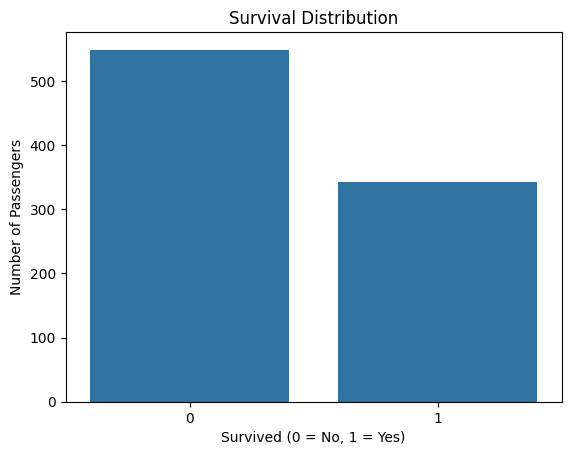

In [450]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Survived')
plt.title('Survival Distribution')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')
plt.show()

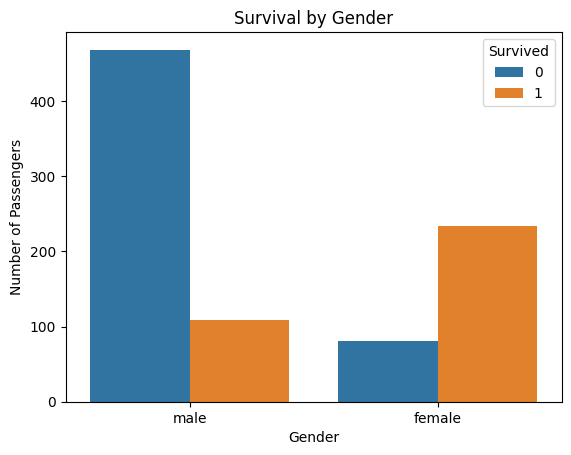

In [451]:
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.show()

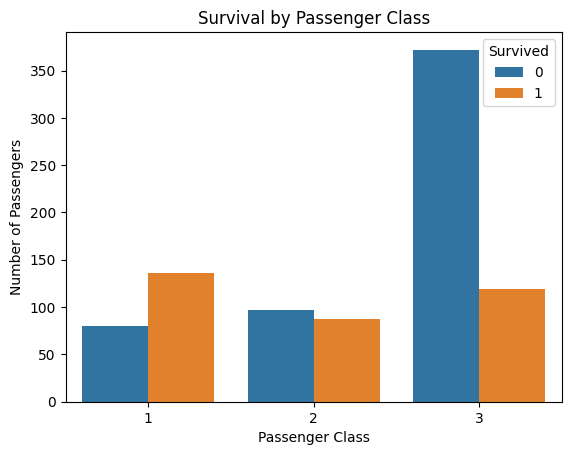

In [452]:
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.show()

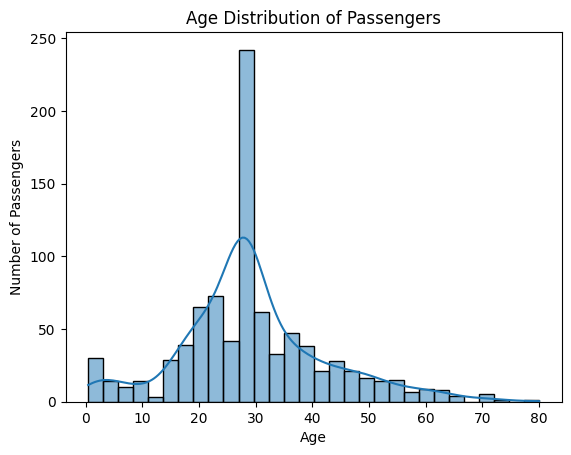

In [453]:
sns.histplot(data=df, x='Age', bins=30, kde=True)
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

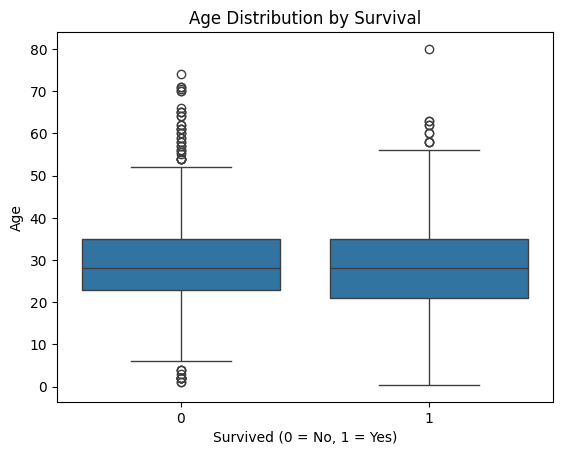

In [454]:
sns.boxplot(data=df, x='Survived', y='Age')
plt.title('Age Distribution by Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

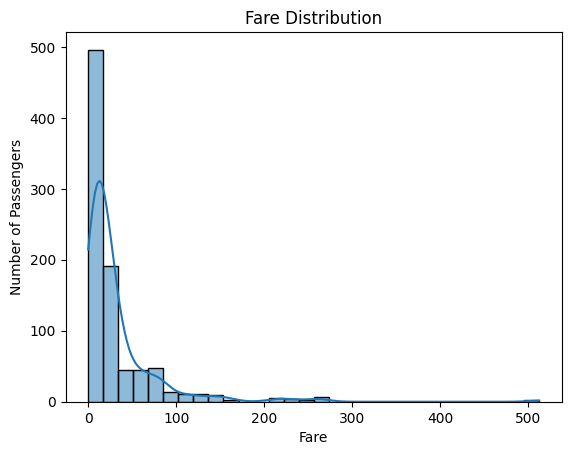

In [455]:
sns.histplot(data=df, x='Fare', bins=30, kde=True)
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Number of Passengers')
plt.show()


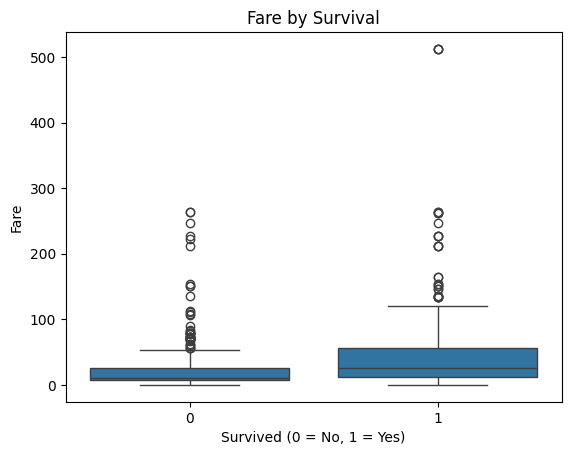

In [456]:
sns.boxplot(data=df, x='Survived', y='Fare')
plt.title('Fare by Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare')
plt.show()

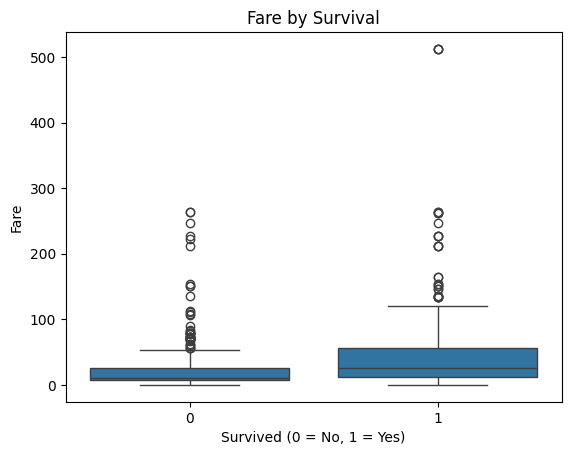

In [457]:
sns.boxplot(data=df, x='Survived', y='Fare')
plt.title('Fare by Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare')
plt.show()

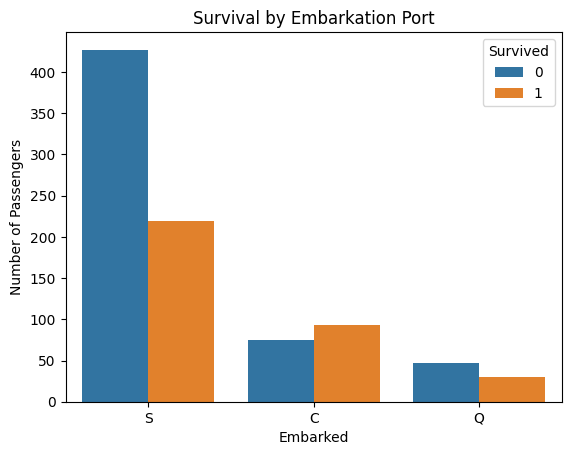

In [458]:
sns.countplot(data=df, x='Embarked', hue='Survived')
plt.title('Survival by Embarkation Port')
plt.xlabel('Embarked')
plt.ylabel('Number of Passengers')
plt.show()

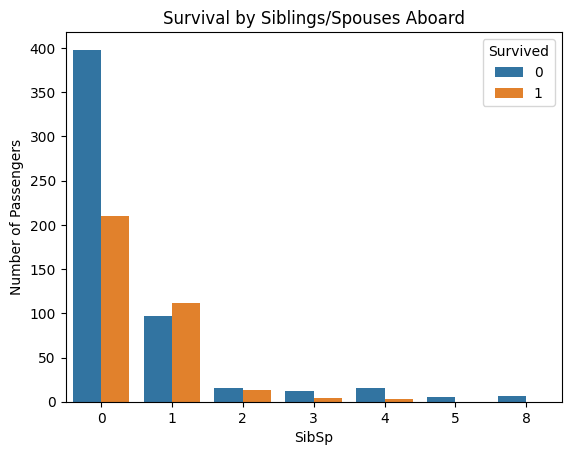

In [459]:
sns.countplot(data=df, x='SibSp', hue='Survived')
plt.title('Survival by Siblings/Spouses Aboard')
plt.xlabel('SibSp')
plt.ylabel('Number of Passengers')
plt.show()

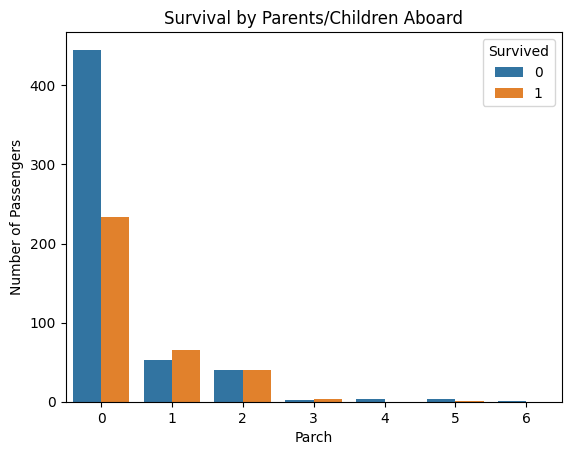

In [460]:
sns.countplot(data=df, x='Parch', hue='Survived')
plt.title('Survival by Parents/Children Aboard')
plt.xlabel('Parch')
plt.ylabel('Number of Passengers')
plt.show()

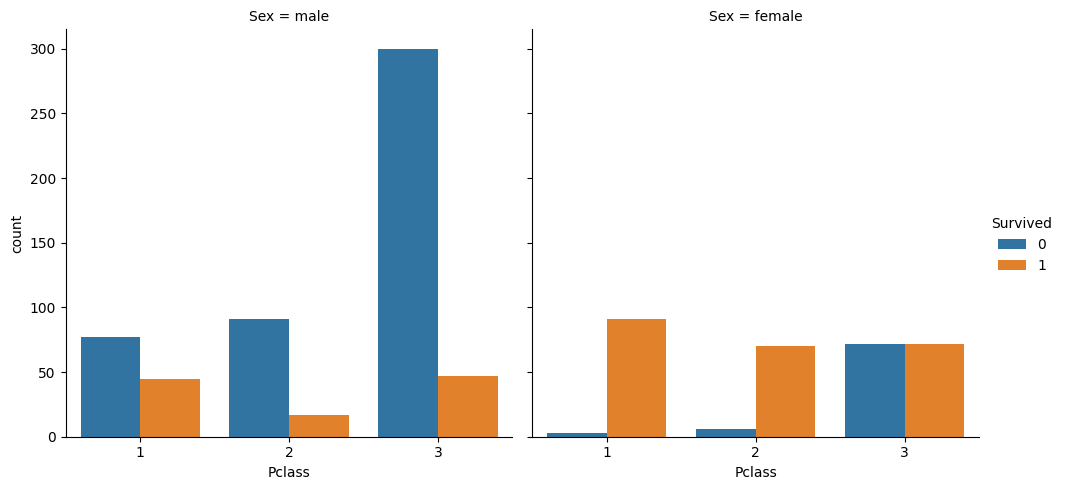

In [461]:
sns.catplot(
    data=df,
    x='Pclass',
    hue='Survived',
    col='Sex',
    kind='count'
)

plt.show()

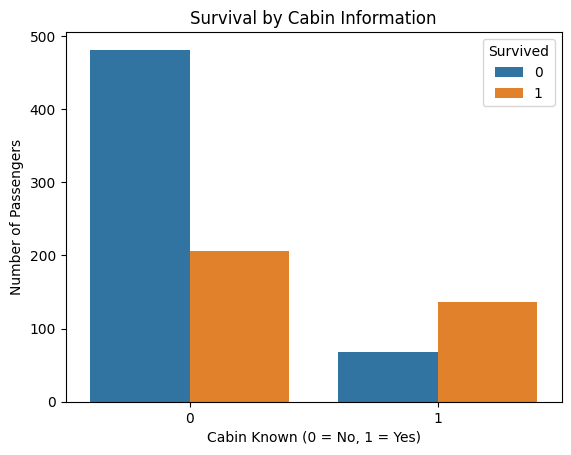

In [462]:
sns.countplot(data=df, x='CabinKnown', hue='Survived')
plt.title('Survival by Cabin Information')
plt.xlabel('Cabin Known (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')
plt.show()

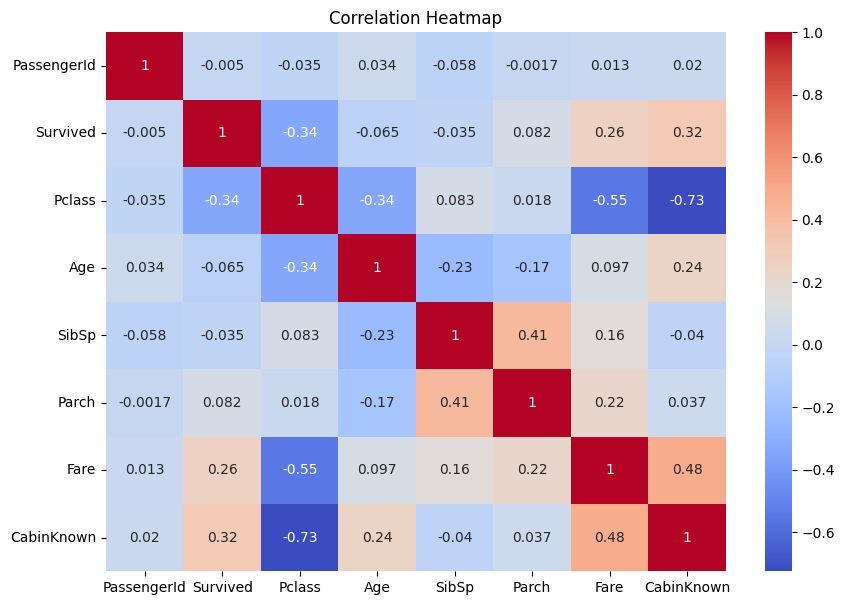

In [463]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [464]:
df['SexEncoded'] = df['Sex'].map({'male': 0, 'female': 1})

In [465]:
df[['Survived', 'SexEncoded']].corr()

,Survived,SexEncoded
Survived,1.000000,0.543351
SexEncoded,0.543351,1.000000


In [466]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [467]:
pd.crosstab(df['FamilySize'], df['Survived'], normalize='index') * 100

Survived,0,1
FamilySize,,
1,69.646182,30.353818
2,44.720497,55.279503
3,42.156863,57.843137
4,27.586207,72.413793
5,80.000000,20.000000
6,86.363636,13.636364
7,66.666667,33.333333
8,100.000000,0.000000
11,100.000000,0.000000


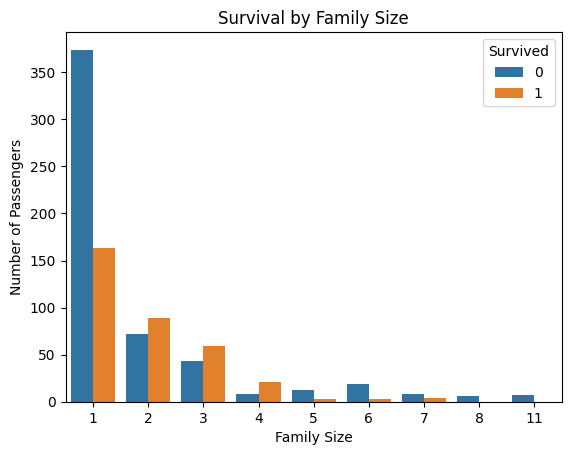

In [468]:
sns.countplot(data=df, x='FamilySize', hue='Survived')
plt.title('Survival by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Number of Passengers')
plt.show()

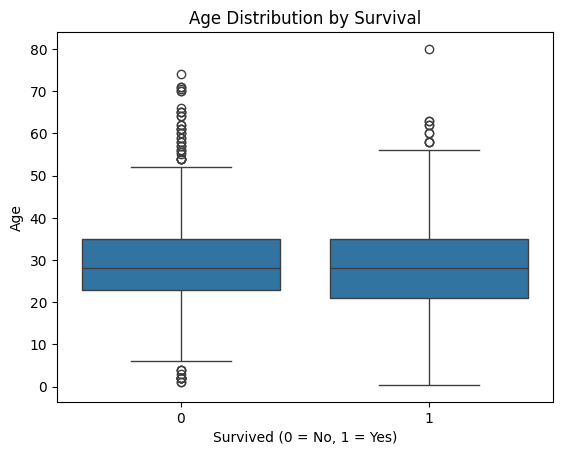

In [469]:
sns.boxplot(data=df, x='Survived', y='Age')
plt.title('Age Distribution by Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

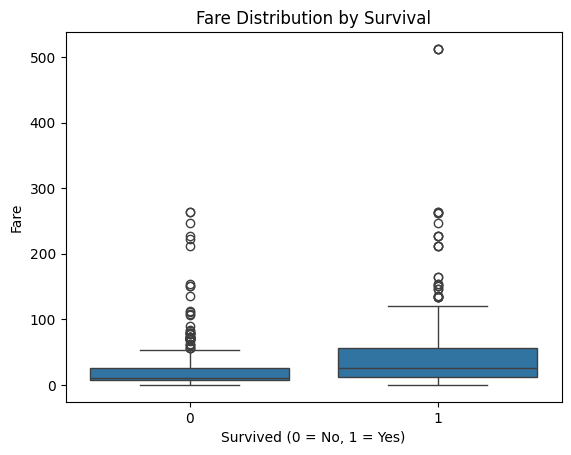

In [470]:
sns.boxplot(data=df, x='Survived', y='Fare')
plt.title('Fare Distribution by Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare')
plt.show()

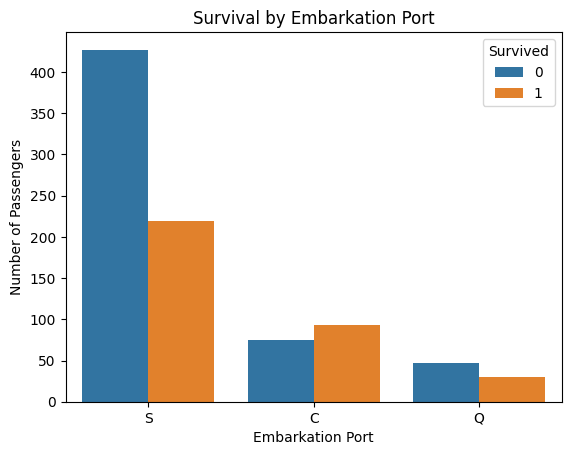

In [471]:
sns.countplot(data=df, x='Embarked', hue='Survived')
plt.title('Survival by Embarkation Port')
plt.xlabel('Embarkation Port')
plt.ylabel('Number of Passengers')
plt.show()

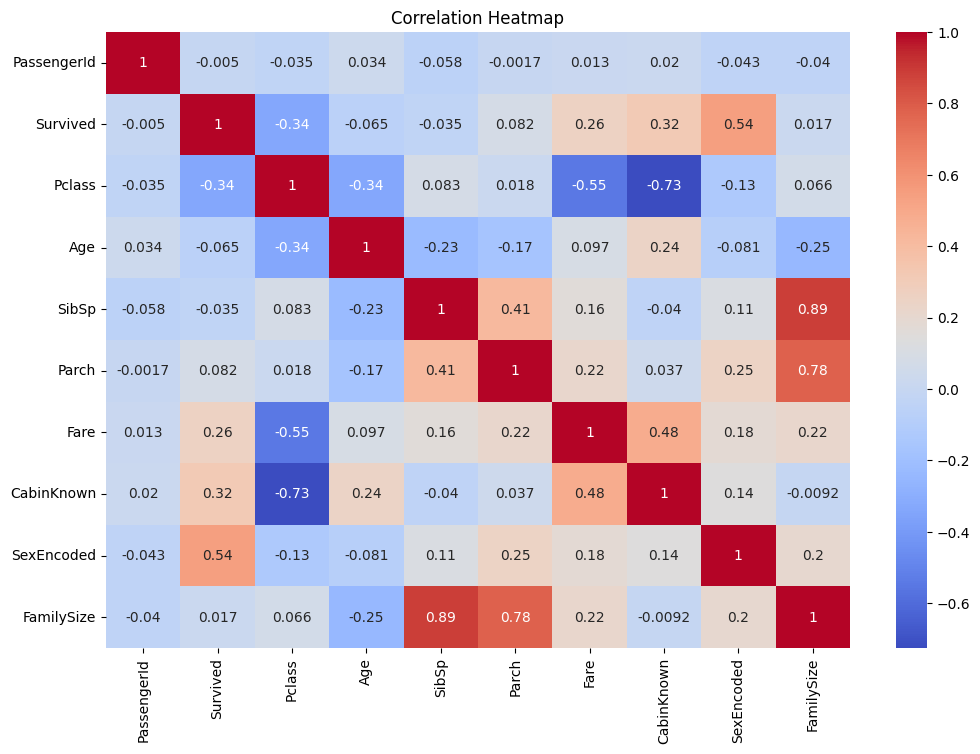

In [472]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## EDA Findings and Conclusion

### Key Findings

1. **Gender and Survival**
   Female passengers had a much higher survival rate (74.2%) compared with male passengers (18.9%). This shows a strong association between gender and survival.

2. **Passenger Class and Survival**
   First-class passengers had the highest survival rate (63.0%), followed by second-class passengers (47.3%) and third-class passengers (24.2%).

3. **Gender and Passenger Class**
   The combination of gender and passenger class revealed an even stronger pattern. First- and second-class females had very high survival rates, while third-class males had the lowest survival rate.

4. **Age and Survival**
   Age showed some differences between survivors and non-survivors, although its relationship with survival was weaker than gender and passenger class.

5. **Fare and Survival**
   Higher fares were generally associated with higher survival rates. Fare also had a positive correlation with survival (0.26).

6. **Cabin Information and Survival**
   Passengers with recorded cabin information had a higher survival rate (66.7%) than passengers without cabin information (30.0%).

7. **Family Size and Survival**
   Family-related variables showed relationships with survival. SibSp and Parch were also positively correlated with each other.

8. **Overall Survival**
   Out of 891 passengers, 342 survived and 549 did not survive. The overall survival rate was approximately 38.4%.

### Conclusion

The exploratory data analysis indicates that gender and passenger class were among the strongest factors associated with survival in the Titanic dataset. Female and higher-class passengers generally had better survival outcomes, while male and third-class passengers had lower survival rates. Fare, cabin information, age, and family-related variables also showed meaningful patterns.

These findings describe associations in the dataset and do not necessarily imply that one variable directly caused survival.

In [473]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
CabinKnown       0
SexEncoded       0
FamilySize       0
dtype: int64

In [474]:
df.shape

(891, 15)